# 02 — Feature engineering

We turn each cell's first-100-cycle data into three nested feature sets (`variance` ⊂ ideas of
`discharge` ⊂ `full`), so the build-up of predictive power is explicit. All logic lives in
`src/features/build_features.py`; this notebook inspects what it produces and why each feature
should carry signal.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from src.data.dataset import load_processed
from src.features import build_features as bf

ds = load_processed()
{name: cols for name, cols in bf.FEATURE_SETS.items()}

{'variance': ['dq_variance'],
 'discharge': ['dq_minimum',
  'dq_variance',
  'dq_skewness',
  'dq_kurtosis',
  'early_discharge_capacity',
  'max_minus_early_capacity'],
 'full': ['dq_minimum',
  'dq_variance',
  'capacity_fade_slope',
  'capacity_fade_intercept',
  'early_discharge_capacity',
  'avg_early_charge_time',
  'mean_temperature',
  'min_internal_resistance',
  'internal_resistance_change']}

## The central object: ΔQ(V)

`delta_q` computes **Q_discharge(cycle 100) − Q_discharge(cycle 10)** on the fixed voltage grid.
Its single most useful summary is `log10 var(ΔQ)` — the `variance` model's lone feature.

In [2]:
dq = bf.delta_q(ds.qdlin['b1c0'])
print('ΔQ(V) length (non-NaN):', dq.size)
print('log10 var(ΔQ):', round(bf.dq_variance(dq), 3))
print('log10 |min(ΔQ)|:', round(bf.dq_minimum(dq), 3))

ΔQ(V) length (non-NaN): 1000
log10 var(ΔQ): -5.015
log10 |min(ΔQ)|: -2.073


## Feature tables and their correlation with the target

We build each table and look at how strongly each feature correlates with `log(cycle life)` on
the **training split only** (looking at test correlations would be peeking).

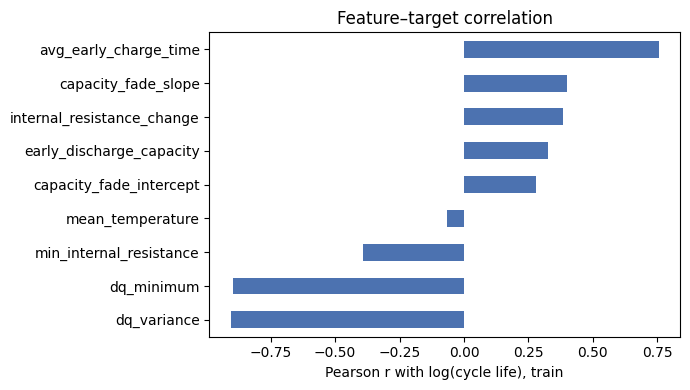

dq_variance                  -0.904
dq_minimum                   -0.894
min_internal_resistance      -0.392
mean_temperature             -0.065
capacity_fade_intercept       0.280
early_discharge_capacity      0.328
internal_resistance_change    0.384
capacity_fade_slope           0.401
avg_early_charge_time         0.755
Name: log_cycle_life, dtype: float64

In [3]:
full = bf.build_feature_table('full')
tr = full[full.split == 'train']
corr = tr[bf.FEATURE_SETS['full'] + ['log_cycle_life']].corr()['log_cycle_life'].drop('log_cycle_life')
corr.sort_values().plot.barh(figsize=(7,4), color='#4C72B0')
plt.xlabel('Pearson r with log(cycle life), train'); plt.title('Feature–target correlation'); plt.tight_layout(); plt.show()
corr.round(3).sort_values()

**Reading it:** the ΔQ(V) statistics (`dq_variance`, `dq_minimum`) and `avg_early_charge_time`
dominate; `mean_temperature` is near zero because every cell was cycled at a controlled 30 °C.
This is why even the 1-feature variance model is competitive, and why adding many weak features
(the full model) yields only modest gains — foreshadowing the overfitting seen in notebook 03.

In [4]:
full.head()

,dq_minimum,dq_variance,capacity_fade_slope,capacity_fade_intercept,early_discharge_capacity,avg_early_charge_time,mean_temperature,min_internal_resistance,internal_resistance_change,cycle_life,log_cycle_life,split
cell_id,,,,,,,,,,,,
b1c0,-2.072649,-5.014856,-0.000207,1.091144,1.070689,2.593379,3.453276,0.016444,-0.000075,1852.0,7.524021,test
b1c1,-1.958456,-5.013956,0.000006,1.080965,1.075301,2.595937,3.444586,0.016764,-0.000042,2160.0,7.677864,train
b1c2,-1.764058,-4.736997,0.000010,1.084846,1.079922,2.592134,3.449339,0.016613,-0.000014,2237.0,7.712891,test
b1c3,-1.722149,-4.442612,0.000017,1.084075,1.079723,2.486999,3.399269,0.016098,0.000039,1434.0,7.268223,train
b1c4,-1.855178,-4.647742,0.000019,1.081875,1.078417,2.488388,3.448363,0.016369,-0.000053,1709.0,7.443664,test
